# **"1. Importing Libraries & Modules"**


In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, explained_variance_score
import yfinance as yf
from keras.models import Sequential
from keras.layers import LSTM, Dense
from keras.callbacks import EarlyStopping

# **"2. Data Collecting"**

In [37]:
stock = 'AAPL'  # Apple Stock Ticker
start_date = '2015-01-01'
end_date = '2024-01-01'
df = yf.download(stock, start=start_date, end=end_date)

[*********************100%***********************]  1 of 1 completed


# **"3. Data Preprocessing"**






# > 3.1 (Removing other parameters except Close price)



In [38]:
data = df['Close'].values.reshape(-1, 1)
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)



# > 3.2 (Splitting data into 80% = Training and 20% = Test)



In [39]:
train_size = int(len(data_scaled) * 0.8)
train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]



# > 3.3 (function to create sequence (loop/epochs) for LSTM)



In [40]:
# we use the time_steep 60 because , 100 training days = 5 months and 60 training days = 3 months , It reduces the memory usage, training time  
# and better for deployment  
def create_dataset(data, time_step=60):
    X, Y = [], []
    for i in range(len(data) - time_step - 1):
        X.append(data[i:(i + time_step), 0])
        Y.append(data[i + time_step, 0])
    return np.array(X), np.array(Y)

time_step = 60
X_train, Y_train = create_dataset(train_data, time_step)
X_test, Y_test = create_dataset(test_data, time_step)



# > 3.4 (Reshaping for LSTM)



In [41]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)


# **"4. Building LSTM Model with MSE"**




In [42]:
# Reducing the units to 32 formm 50 for faster training,lower RAM, smaller model size.
mse_model = Sequential([
    LSTM(
        units=32,
        return_sequences=True,
        input_shape=(time_step, 1)
    ),

    LSTM(
        units=32,
        return_sequences=False
    ),

    Dense(
        units=25,
        activation='relu'
    ),

    Dense(
        units=1
    )
])

mse_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)


/Users/ruda/Documents/Projects/AI_PROJECT/THE PROOOO/.venv/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [43]:
# Early stopping 
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# **"5. Training LSTM model with MSE "**




In [44]:
history_mse = mse_model.fit(
    X_train,
    Y_train,
    validation_data=(X_test, Y_test),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0173 - val_loss: 0.0025
Epoch 2/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 4.9411e-04 - val_loss: 0.0036
Epoch 3/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.7891e-04 - val_loss: 0.0036
Epoch 4/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.3223e-04 - val_loss: 0.0023
Epoch 5/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.6310e-04 - val_loss: 0.0023
Epoch 6/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.2160e-04 - val_loss: 0.0025
Epoch 7/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3.6138e-04 - val_loss: 0.0014
Epoch 8/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3.4823e-04 - val_loss: 0.0019
Epoch 9/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 4.0960e-04 - val_loss: 0.0012
Epoch 10/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 3.3969e-04 - val_loss: 0.0013
Epoch 11/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 3.0489e-04 - val_loss: 0.0021
Epoch 12/100

# **"6. Building LSTM model with MAE "**




In [45]:
mae_model = Sequential([
    LSTM(
        units=32,
        return_sequences=True,
        input_shape=(time_step, 1)
    ),

    LSTM(
        units=32,
        return_sequences=False
    ),

    Dense(
        units=25,
        activation='relu'
    ),

    Dense(
        units=1
    )
])

mae_model.compile(
    optimizer='adam',
    loss='mean_absolute_error'
)

# **"7. Training MAE Model"**




In [46]:
history_mae = mae_model.fit(
    X_train,
    Y_train,
    validation_data=(X_test, Y_test),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0496 - val_loss: 0.0378
Epoch 2/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0143 - val_loss: 0.0343
Epoch 3/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0124 - val_loss: 0.0398
Epoch 4/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0126 - val_loss: 0.0299
Epoch 5/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0114 - val_loss: 0.0315
Epoch 6/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0117 - val_loss: 0.0272
Epoch 7/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0110 - val_loss: 0.0233
Epoch 8/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0106 - val_loss: 0.0262
Epoch 9/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0114 - val_loss: 0.0282
Epoch 10/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0101 - val_loss: 0.0289


In [47]:
# Saving the trained LSTM model in .keras format
mse_model.save('mse_model.keras')

# Saving the trained MAE model in .keras format
mae_model.save('mae_model.keras')

# Optionally, save the scaler (if needed later for preprocessing)
# .keras cannot save the python objects so we use pickle
import pickle
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)


# **"8. Making the predictions"**




In [48]:
# lstm model prediction
mse_predictions = mse_model.predict(X_test)
mse_predictions = scaler.inverse_transform(mse_predictions.reshape(-1, 1))
# mae model prediction
mae_predictions = mae_model.predict(X_test)
mae_predictions = scaler.inverse_transform(mae_predictions.reshape(-1, 1))

Y_test_actual = scaler.inverse_transform(Y_test.reshape(-1, 1))

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


# **"9. Visualizing (Comparison and Predictions)"**




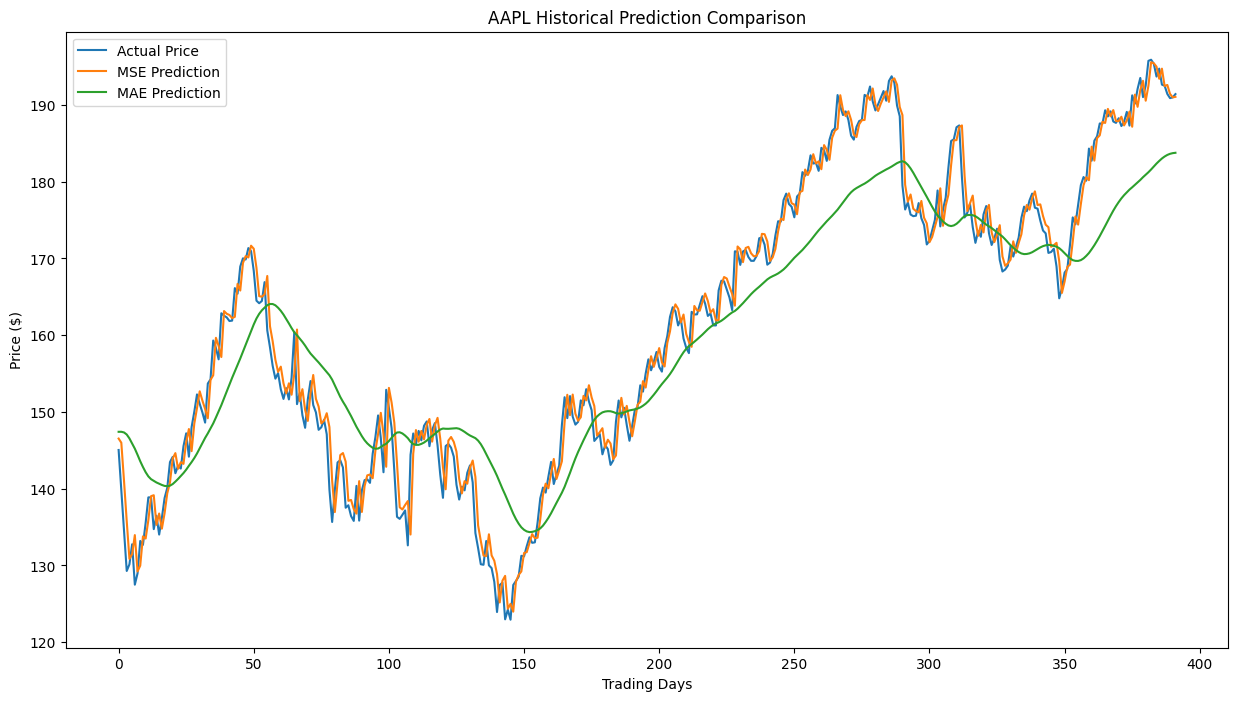

In [51]:
plt.figure(figsize=(15,8))

plt.plot(
    Y_test_actual,
    label="Actual Price"
)

plt.plot(
    mse_predictions,
    label="MSE Prediction"
)

plt.plot(
    mae_predictions,
    label="MAE Prediction"
)

plt.title(
    f"{stock} Historical Prediction Comparison"
)

plt.xlabel("Trading Days")
plt.ylabel("Price ($)")
plt.legend()

plt.show()

# **"10. Evaluating Metrics for the Lstm_mae model "**




In [52]:
# ==========================
# Evaluation Metrics
# ==========================

mse_mae = mean_absolute_error(
    Y_test_actual,
    mse_predictions
)

mse_rmse = np.sqrt(
    mean_squared_error(
        Y_test_actual,
        mse_predictions
    )
)

mse_mape = np.mean(
    np.abs(
        (Y_test_actual - mse_predictions)
        / Y_test_actual
    )
) * 100

mse_r2 = r2_score(
    Y_test_actual,
    mse_predictions
)

mse_evs = explained_variance_score(
    Y_test_actual,
    mse_predictions
)

print("\n===== MSE Model =====")
print(f"MAE : {mse_mae:.4f}")
print(f"RMSE: {mse_rmse:.4f}")
print(f"MAPE: {mse_mape:.2f}%")
print(f"R2  : {mse_r2:.4f}")
print(f"EVS : {mse_evs:.4f}")


===== MSE Model =====
MAE : 1.9783
RMSE: 2.6321
MAPE: 1.28%
R2  : 0.9812
EVS : 0.9815


# **"10. Evaluating Metrics for the Lstm_mse model "**




In [53]:
mae_mae = mean_absolute_error(
    Y_test_actual,
    mae_predictions
)

mae_rmse = np.sqrt(
    mean_squared_error(
        Y_test_actual,
        mae_predictions
    )
)

mae_mape = np.mean(
    np.abs(
        (Y_test_actual - mae_predictions)
        / Y_test_actual
    )
) * 100

mae_r2 = r2_score(
    Y_test_actual,
    mae_predictions
)

mae_evs = explained_variance_score(
    Y_test_actual,
    mae_predictions
)

print("\n===== MAE Model =====")
print(f"MAE : {mae_mae:.4f}")
print(f"RMSE: {mae_rmse:.4f}")
print(f"MAPE: {mae_mape:.2f}%")
print(f"R2  : {mae_r2:.4f}")
print(f"EVS : {mae_evs:.4f}")


===== MAE Model =====
MAE : 6.6207
RMSE: 7.8647
MAPE: 4.15%
R2  : 0.8317
EVS : 0.8368


# **"11. Training Curves"**




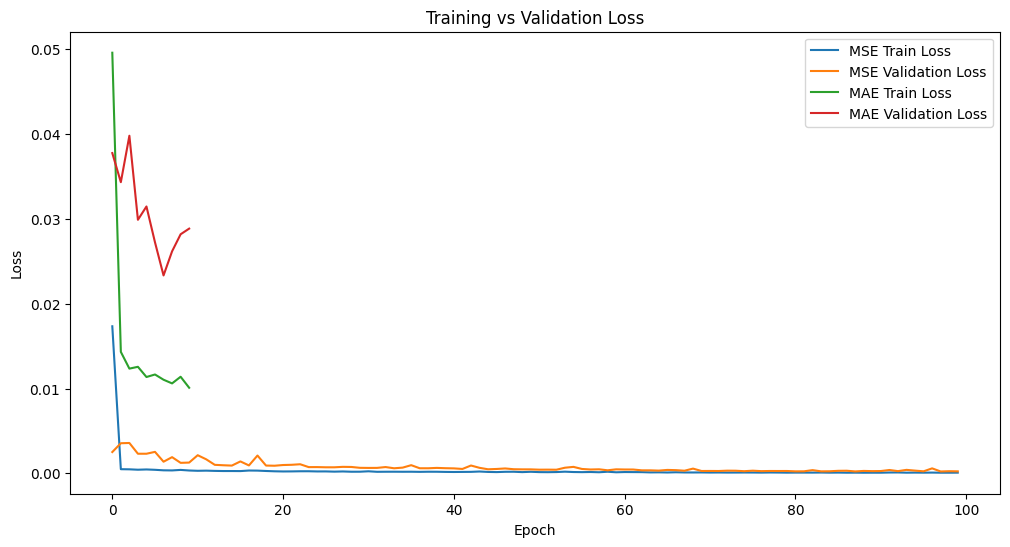

In [54]:
# ==========================
# Training Curves
# ==========================

plt.figure(figsize=(12,6))

plt.plot(
    history_mse.history['loss'],
    label='MSE Train Loss'
)

plt.plot(
    history_mse.history['val_loss'],
    label='MSE Validation Loss'
)

plt.plot(
    history_mae.history['loss'],
    label='MAE Train Loss'
)

plt.plot(
    history_mae.history['val_loss'],
    label='MAE Validation Loss'
)

plt.title(
    'Training vs Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()
plt.show()

# **"12. Model comparision Table"**




In [55]:
comparison_df = pd.DataFrame({
    "Model": ["MSE", "MAE"],
    "MAE": [mse_mae, mae_mae],
    "RMSE": [mse_rmse, mae_rmse],
    "MAPE": [mse_mape, mae_mape],
    "R2": [mse_r2, mae_r2],
    "EVS": [mse_evs, mae_evs]
})

print("\nModel Comparison")
print(comparison_df)


Model Comparison
  Model       MAE      RMSE      MAPE        R2       EVS
0   MSE  1.978313  2.632063  1.275863  0.981152  0.981522
1   MAE  6.620721  7.864742  4.154083  0.831713  0.836773
